# Continual Word Sequence Recall

This notebook evaluates the MemVal framework's capacity for **Continual Sequence Learning** using discrete, symbolic data.
We use a `SymbolicEncoder` to generate synthetic semantic embeddings for a vocabulary of words.
The task involves:
1. **Episodic Recall**: Learning a single sequence of words and evaluating recall probability (Primacy/Recency).
2. **Continual List Learning**: Sequentially learning multiple lists of words to test for catastrophic forgetting (retroactive interference).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

from memval.encoders import SymbolicEncoder, SymbolicDecoder
from memval.models.baselines.dg_eqprop import DGEqPropSequenceNetwork

# Set plotting style
plt.style.use('dark_background')
sns.set_palette('husl')


## 1. Setup Symbolic Vocabulary and Encoder

We define a vocabulary mapped to semantic categories. The `SymbolicEncoder` will map words in the same category to vectors with higher cosine similarity than words in different categories.


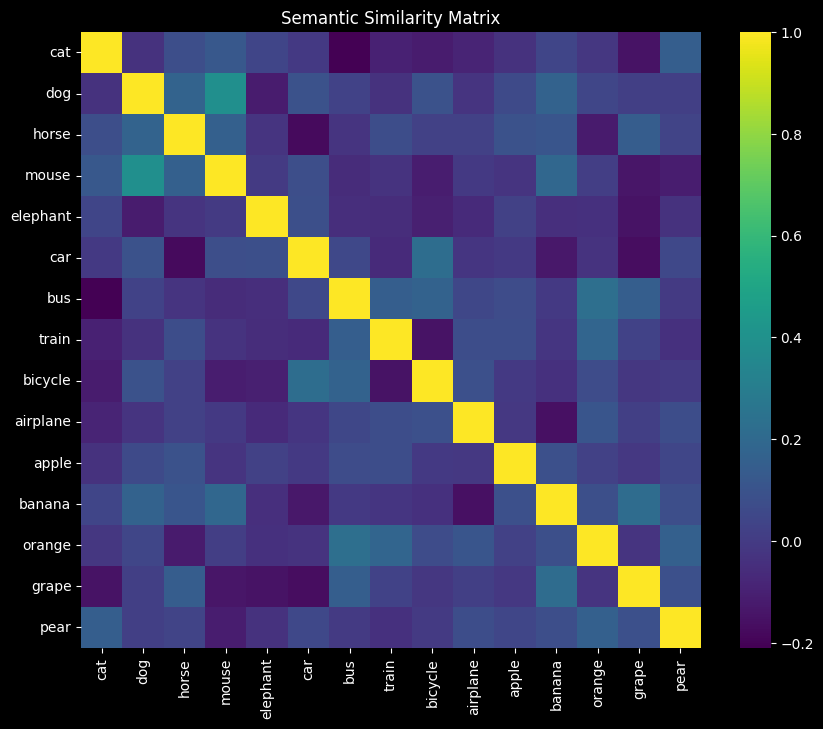

In [2]:
vocab = {
    # Animals
    'cat': 'animal', 'dog': 'animal', 'horse': 'animal', 'mouse': 'animal', 'elephant': 'animal',
    # Vehicles
    'car': 'vehicle', 'bus': 'vehicle', 'train': 'vehicle', 'bicycle': 'vehicle', 'airplane': 'vehicle',
    # Fruits
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit'
}

# 100-dimensional embeddings, high variance for some uniqueness but obvious categorization
encoder = SymbolicEncoder(vocab, embedding_dim=100, category_variance=0.3, seed=42)
decoder = SymbolicDecoder(encoder)

# Visualize the semantic similarity matrix
words = list(vocab.keys())
encoded_words = encoder.encode(words)

sim_matrix = cosine_similarity(encoded_words)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, xticklabels=words, yticklabels=words, cmap='viridis')
plt.title("Semantic Similarity Matrix")
plt.show()


## 2. Capacity Test: Miller's Law (7 ± 2)

Cognitively, human short-term memory capacity is typically cited as **7 ± 2** items. Beyond this, recall performance for middle items begins to drop sharply, forming the "U-shaped" curve. 

In this section, we test the model's capacity by presenting a single list of **12 words** (all fruits) in a single context. We introduce noise during recall to simulate the challenge of retrieving these items from memory.


Training on 12-item list (50 epochs)...
Measuring recall probability...


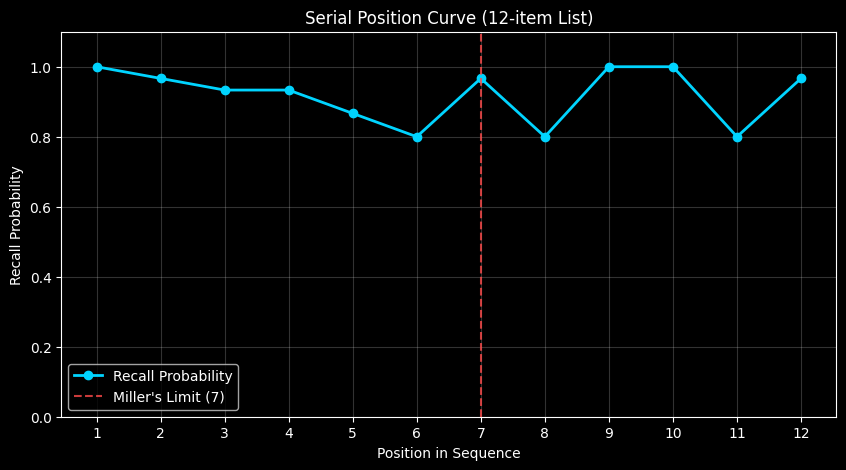

In [4]:
# Define a long list of 12 words (all fruits)
long_list = ['apple', 'banana', 'orange', 'grape', 'pear', 'peach', 'plum', 'cherry', 'kiwi', 'mango', 'lemon', 'lime']
capacity_vocab = {w: 'fruit' for w in long_list}

# Fresh encoder for this list
cap_encoder = SymbolicEncoder(capacity_vocab, embedding_dim=100, category_variance=0.2, seed=42)
cap_decoder = SymbolicDecoder(cap_encoder)
seq_long_enc = cap_encoder.encode(long_list)

# Initialize a fresh network for the capacity test
net_cap = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=500, seed=42)
context_cap = np.array([1.0])
context_cap_seq = np.tile(context_cap, (len(long_list), 1))

print("Training on 12-item list (50 epochs)...")
net_cap.fit_sequence(seq_long_enc, context_data=context_cap_seq)

# Reuse the measurement function (defined later in the original script, so we'll move its definition up)
def measure_recall_probability(network, target_list, context, encoder_obj, decoder_obj, n_trials=20, noise_scale=0.1):
    success_counts = np.zeros(len(target_list))
    for _ in range(n_trials):
        for i in range(len(target_list) - 1):
            true_evt = encoder_obj.encode([target_list[i]])[0]
            noisy_evt = true_evt + np.random.normal(0, noise_scale, true_evt.shape)
            pred = network.predict_next(noisy_evt, current_context=context)
            pred_word = decoder_obj.decode(pred, top_k=1)[0]
            if pred_word == target_list[i+1]:
                success_counts[i+1] += 1
        success_counts[0] = n_trials
    return success_counts / n_trials

print("Measuring recall probability...")
probs_cap = measure_recall_probability(net_cap, long_list, context_cap, cap_encoder, cap_decoder, n_trials=30, noise_scale=0.1)

# Plot the Serial Position Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(long_list)+1), probs_cap, marker='o', color='#00d4ff', linewidth=2, label="Recall Probability")
plt.axvline(x=7, color='#ff4b4b', linestyle='--', alpha=0.8, label="Miller's Limit (7)")
plt.title("Serial Position Curve (12-item List)")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.xticks(range(1, 13))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 3. Phase 1: Episodic Sequence Recall (Single List)


In [ ]:
# Prepare sequences
list_a = ['cat', 'dog', 'horse', 'mouse', 'elephant']
list_b = ['car', 'bus', 'train', 'bicycle', 'airplane']
list_c = ['apple', 'banana', 'orange', 'grape', 'pear']

seq_a_enc = encoder.encode(list_a) # Shape (5, 100)

# Initialize DGEqProp Network
# We use 0 internal context and 1 explicit context (the list ID)
net = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=50, seed=42)

# List A Context (List ID 1.0)
context_a = np.array([1.0])
context_a_seq = np.tile(context_a, (len(list_a), 1))

# Train on List A
print("Training List A (50 epochs)...")
net.fit_sequence(seq_a_enc, context_data=context_a_seq)

# Recall test for List A
def test_recall(network, sequence, start_word, context, steps=4):
    start_enc = encoder.encode([start_word])[0]
    
    current_evt = start_enc
    recalled_words = [start_word]
    network.reset_context() # Reset internal context if any
    
    for i in range(steps):
        # EqProp expects single timestep inputs for predict_next
        next_evt = network.predict_next(current_evt, current_context=context)
        # Decode the predicted vector
        pred_word = decoder.decode(next_evt, top_k=1)[0]
        recalled_words.append(pred_word)
        # Auto-regressive recall
        current_evt = next_evt
        
    return recalled_words

recalled_a = test_recall(net, list_a, list_a[0], context_a, steps=len(list_a)-1)
print("Target List A:  ", list_a)
print("Recalled List A:", recalled_a)

accuracy = sum([1 for r, t in zip(recalled_a, list_a) if r == t]) / len(list_a)
print(f"Recall Accuracy: {accuracy*100:.1f}%")


## 4. Phase 2: Continual List Learning

To test for catastrophic forgetting, we will now train the network on List B and List C sequentially, using different context signals.
Then, we will re-test its recall on List A.


In [ ]:
seq_b_enc = encoder.encode(list_b)
seq_c_enc = encoder.encode(list_c)

context_b = np.array([2.0])
context_c = np.array([3.0])
context_b_seq = np.tile(context_b, (len(list_b), 1))
context_c_seq = np.tile(context_c, (len(list_c), 1))

print("Training List B...")
net.fit_sequence(seq_b_enc, context_data=context_b_seq)

print("Training List C...")
net.fit_sequence(seq_c_enc, context_data=context_c_seq)

# Retest List A
recalled_a_after = test_recall(net, list_a, list_a[0], context_a, steps=len(list_a)-1)
print("\nTarget List A:  ", list_a)
print("Recalled List A:", recalled_a_after)

accuracy_after = sum([1 for r, t in zip(recalled_a_after, list_a) if r == t]) / len(list_a)
print(f"List A Retention Accuracy: {accuracy_after*100:.1f}%")

# Retest B and C to prove they were learned
recalled_b = test_recall(net, list_b, list_b[0], context_b, steps=len(list_b)-1)
recalled_c = test_recall(net, list_c, list_c[0], context_c, steps=len(list_c)-1)
print("\nRecalled List B:", recalled_b)
print("Recalled List C:", recalled_c)


## 5. Visualizing Primacy and Recency Effects

In biological memory systems, elements at the beginning (Primacy) and end (Recency) of a sequence are typically recalled with higher probability than middle elements. 
We can simulate this by introducing noise during recall and measuring the probability of successful recall across many trials.


In [ ]:
def measure_recall_probability(network, target_list, context, n_trials=10, noise_scale=0.2):
    success_counts = np.zeros(len(target_list))
    
    for _ in range(n_trials):
        # Start from the first word
        current_evt = encoder.encode([target_list[0]])[0]
        # Add noise to the starting cue to make recall challenging
        current_evt += np.random.normal(0, noise_scale, current_evt.shape)
        
        # We assume the first word is 'given' for free, but we count it as recalled 
        # if the starting cue was enough to trigger the first transition.
        # Actually, let's test if it successfully predicts word i+1 given word i (with noise)
        for i in range(len(target_list) - 1):
            true_evt = encoder.encode([target_list[i]])[0]
            noisy_evt = true_evt + np.random.normal(0, noise_scale, true_evt.shape)
            
            pred = network.predict_next(noisy_evt, current_context=context)
            pred_word = decoder.decode(pred, top_k=1)[0]
            
            if pred_word == target_list[i+1]:
                success_counts[i+1] += 1
                
        # First word is always present (cue)
        success_counts[0] = n_trials
        
    return success_counts / n_trials

probs_a = measure_recall_probability(net, list_a, context_a)
probs_b = measure_recall_probability(net, list_b, context_b)
probs_c = measure_recall_probability(net, list_c, context_c)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(list_a)+1), probs_a, marker='o', label='List A (Oldest)')
plt.plot(range(1, len(list_b)+1), probs_b, marker='s', label='List B')
plt.plot(range(1, len(list_c)+1), probs_c, marker='^', label='List C (Newest)')

plt.title("Serial Position Recall Probability")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability (with noise)")
plt.xticks(range(1, 6))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()
